In [7]:
import sys
import os
from pathlib import Path

from section_identification.preprocess import preprocess_image
from section_identification.filtering import filtering
from section_identification.section_detector import automatic_identification

package_path = Path(os.path.abspath("")).parent
apply_filtering = True

example1 = package_path / "images/example1.png"
example2 = package_path / "images/example2.png"
example3 = package_path / "images/example3.png"
example4 = package_path / "images/example4.png"

# the weights can be downloaded from: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
checkpoint = package_path.parents[0] / "checkpoint/sam_vit_h_4b8939.pth" 


Image shape: (4999, 5000, 3)
Loaded cached masks.
Filtering masks...
Most common largest cluster size: 6 out of 41 total masks.
Chosen parameters: eps=320.0, min_samples=1
Filtering completed with chosen parameters: (np.float64(320.0), 1)


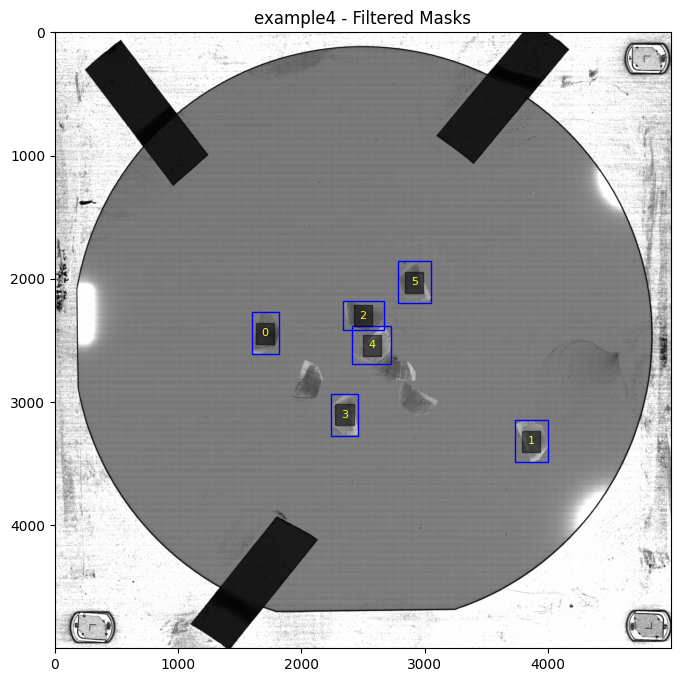

Time taken to run automatic_identification for example4.png: 0.98 seconds
Number of masks identified: 6


In [8]:
# Write filtering=True to only identify sections
masks = automatic_identification(example4, checkpoint=checkpoint, compress=False, apply_filtering=True)
print(f"Number of masks identified: {len(masks)}")


In [9]:
from section_identification.interactive import run_sam_interactive

new_masks, stored_masks, fiducials = run_sam_interactive(example4, checkpoint, masks, model_type="vit_h", device="cpu")

Quantized ONNX model already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_onnx_quantized.onnx
[Info] Embedding already exists: /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_embedding.npy
Image size: 5000x4999 (width x height), samScale: 0.205
Processing mask 1/6
Processing mask 2/6
Processing mask 3/6
Processing mask 4/6
Processing mask 5/6
Processing mask 6/6
[Info] Starting interactive segmentation. Move the mouse over the image to update mask.
New mask added at position (2782, 2743, 1)
New mask added at position (2894, 2987, 1)
New mask added at position (2114, 2862, 1)
Fiducial saved at coordinates (288, 4804)
Fiducial saved at coordinates (4831, 4839)
Fiducial markers collected: [(288, 4804), (4831, 4839)]
[Info] Exiting interactive segmentation.


Exported mask coordinates to /Users/fredericoaraujo/Documents/section_identification/images/example4_files/example4_mask_coordinates.csv


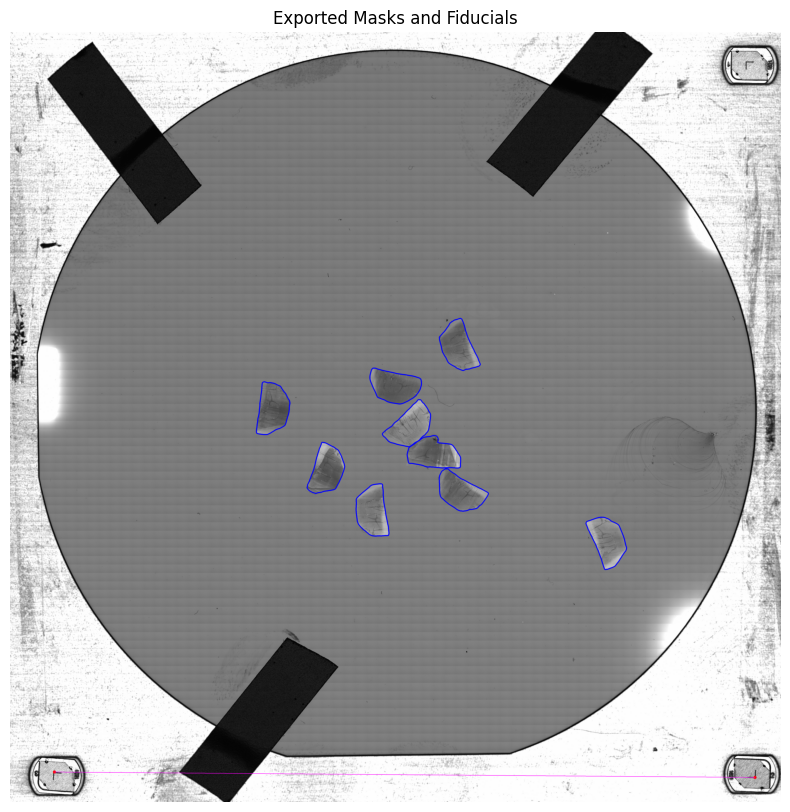

In [10]:
from section_identification.export import export_mask_coordinates
csv_path = export_mask_coordinates(example4, new_masks, stored_masks, fiducials, visualize=True, sample_points=None)

In [15]:
from ruler import run_ruler


img_path = "/Users/fredericoaraujo/Documents/force_sensor/Data/Experiment 16/photos/1.png"
calibration_path_075 = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/0.75.png"
calibration_path_1 = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/1.0.png"
calibration_path_125 = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/1.25.png"
calibration_path_1_new = "/Users/fredericoaraujo/Documents/force_sensor/Data/Measurements_calibration/1.0_new.png"

magnification = 0.75  # e.g. 0.75x
original_length_mm = 7.595  # Original reference length in mm
measurements = run_ruler(img_path, magnification, original_length_mm)
print("Final Measurements:")
for meas in measurements:
    print(meas)

[Debug] Using calibrated scale: effective_pixels_per_mm = 93.96, conversion_factor = 0.010643 mm/pixel
[Info] Exiting ruler interface.
Final Measurements:
((611, 287), (1266, 391), 7.058376931483896, 0.9293452181018955)
((694, 604), (984, 670), 3.1653419990185934, 0.41676655681614133)
((592, 374), (1229, 552), 7.039190061211528, 0.926818967901452)


In [ ]:
from section_identification.thesis import export_contour_image
export_contour_image(csv_path, example2)

Exported image with contours to /Users/fredericoaraujo/Documents/section_identification/images/example2_files/example2_final_drawing.png


'/Users/fredericoaraujo/Documents/section_identification/images/example2_files/example2_final_drawing.png'

In [19]:
from section_identification.thesis import create_composite_image
# Set your folder paths
folder_before = "/Users/fredericoaraujo/Library/Mobile Documents/com~apple~CloudDocs/Harvard classes/ES 100/Image Library/Section_targeting/before_manual_detector"
folder_after  = "/Users/fredericoaraujo/Library/Mobile Documents/com~apple~CloudDocs/Harvard classes/ES 100/Image Library/Section_targeting/after_manual_detector"

# Create the composite image by calling the function
create_composite_image(folder_before, folder_after, output_filename="my_composite.jpg", max_rows=7)

Composite image saved as my_composite.jpg
